# No-Ks Bias Check

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CF_DATA = Path('cf_data')

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': False,
    'ytick.right': False,
    'axes.linewidth': 1.1,
    'axes.grid': False,
})

C = '#9B8EC4'  # muted lavender

cfrc = pd.read_csv(CF_DATA / 'cf_rotator_catalog.csv', dtype={'GaiaDR3_ID': 'Int64'})

has_ks = cfrc[cfrc['k_m'].notna()]
no_ks  = cfrc[cfrc['k_m'].isna()]

print(f'Has Ks: {len(has_ks)} | No Ks: {len(no_ks)}')

Has Ks: 5457 | No Ks: 375


## Color Distribution

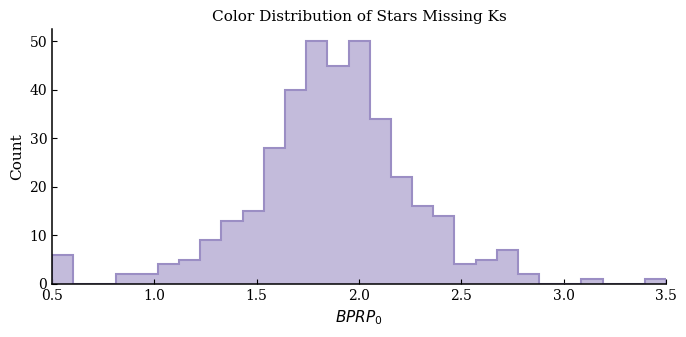

In [45]:
fig, ax = plt.subplots(figsize=(7, 3.5))

bins = np.linspace(0.5, 3.5, 30)

ax.hist(no_ks['BPRP0'].clip(0.5, 3.5), bins=bins,
        histtype='stepfilled', alpha=0.6, color=C)
ax.hist(no_ks['BPRP0'].clip(0.5, 3.5), bins=bins,
        histtype='step', lw=1.5, color=C)

ax.set_title('Color Distribution of Stars Missing Ks')
ax.set_xlabel(r'$BPRP_0$')
ax.set_ylabel('Count')
ax.set_xlim(0.5, 3.5)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Age Distribution

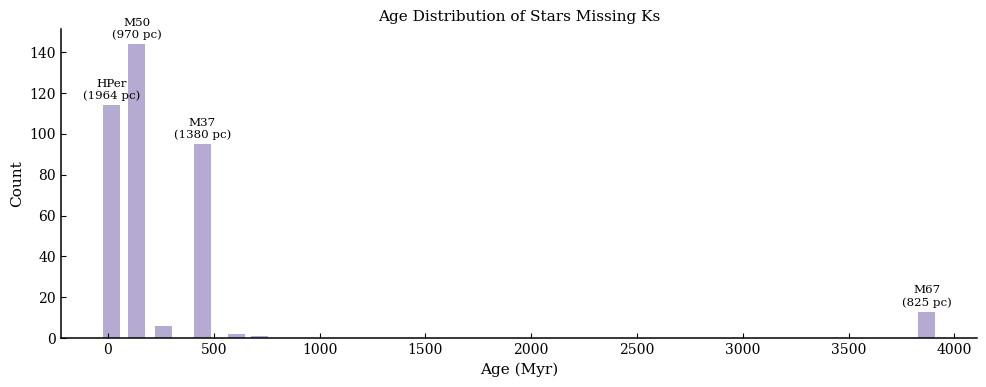

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))

SKIP_CLUSTERS = {'NGC2516', 'NGC2281', 'Praesepe'}

age_labels = {}
for age, grp in no_ks.groupby('age_Myr'):
    name = grp['subgroup'].value_counts().index[0]
    if name in SKIP_CLUSTERS:
        continue
    dist = grp['sampled_avg_dist_pc'].median()
    age_labels[age] = f'{name}\n({dist:.0f} pc)'

unique_ages = np.sort(no_ks['age_Myr'].unique())
counts = no_ks['age_Myr'].value_counts().reindex(unique_ages, fill_value=0)

ax.bar(unique_ages, counts, width=80,
       color=C, alpha=0.75, edgecolor='none')

for age, count in zip(unique_ages, counts):
    if age in age_labels:
        ax.text(age, count + 2, age_labels[age],
                ha='center', va='bottom', fontsize=8.5, color='k')

ax.set_title('Age Distribution of Stars Missing Ks')
ax.set_xlabel('Age (Myr)')
ax.set_ylabel('Count')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Color vs Age

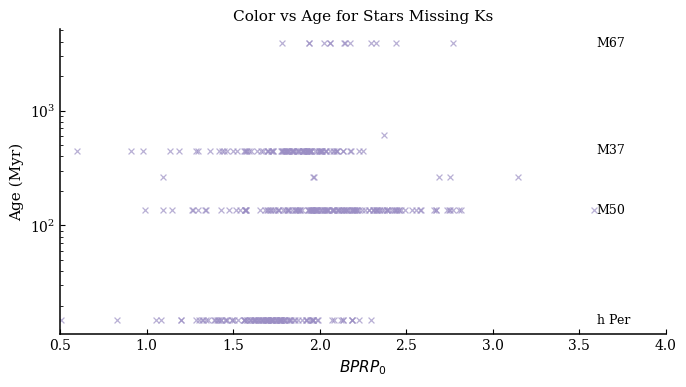

In [48]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(no_ks['BPRP0'], no_ks['age_Myr'],
           s=18, alpha=0.7, color=C, marker='x', lw=0.9)

row_labels = {15: 'h Per', 135: 'M50', 446: 'M37', 3870: 'M67'}
for age, name in row_labels.items():
    ax.annotate(name, xy=(3.5, age), xytext=(3.6, age),
                va='center', fontsize=9, color='k')

ax.set_title('Color vs Age for Stars Missing Ks')
ax.set_yscale('log')
ax.set_xlabel(r'$BPRP_0$')
ax.set_ylabel('Age (Myr)')
ax.set_xlim(0.5, 4.0)
plt.tight_layout()
plt.show()